In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('../..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## LOAD DATASET

In [3]:
from src.CHM.model import ConceptBottleneckClassifier
from src.CHM.train import train_cbm_classifier
import matplotlib.pyplot as plt
import torch.nn as nn
from src.CHM.test import test_cbm_classifier
from src.utils.plot import plot_test_results, plot_concept_error_heatmap, analyze_misclassifications_concepts, plot_concept_uncertainty_heatmap

AllenNLP not available. Registrable won't work.


In [4]:
from src.utils.dataset import load_concept_data, prepare_class_concept_dataset, parse_classes, parse_concepts
import torch
import numpy as np

concepts = parse_concepts('../../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt')
classes = parse_classes('../../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt')
class2id = {c: idx for idx, c in enumerate(classes)}
class_concept_matrix = torch.from_numpy(np.loadtxt('../../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))
dataset, concept2id, id2concept = load_concept_data('../../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json', concepts)
datasetClasses = prepare_class_concept_dataset(class_concept_matrix, class2id)

In [5]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset

features_path = '../../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)

BATCH_SIZE = 32
EPOCHS = 6
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


## CBM LINEAR CLASSIFIER

### Load Boxes

In [6]:
from src.BOX.model import BoxHierarchyModel, BoxHierarchyModelJoint
import torch
from src.utils.box import get_box_dict, get_geometric_class_weights, prepara_tensore_box

BOX_DIM = 16

box_model = BoxHierarchyModel(num_concepts=len(concepts), dim=BOX_DIM)
box_model.load_state_dict(torch.load("../../AwA2_Dataset_Labels/Animals_with_Attributes2/modello_gerarchia.pth"))
box_dict = get_box_dict(box_model, id2concept)
box_tensors = prepara_tensore_box(box_dict, concept2id)

### CBM with boxes

#### Train

In [7]:
info = "boxes"  
b_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(b_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
b_history = train_cbm_classifier(
        b_model, 
        train_dataloader, 
        val_dataloader, 
        optimizer, 
        criterion, 
        class_concept_matrix, 
        box_tensors, 
        EPOCHS, 
        device
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/6 | TRAIN: Loss=0.160, Acc=98.1% | VAL: Loss=0.007, Acc=100.0%
Epoca   3/6 | TRAIN: Loss=0.004, Acc=100.0% | VAL: Loss=0.002, Acc=100.0%
Epoca   4/6 | TRAIN: Loss=0.002, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   5/6 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   6/6 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   7/6 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Addestramento completato.


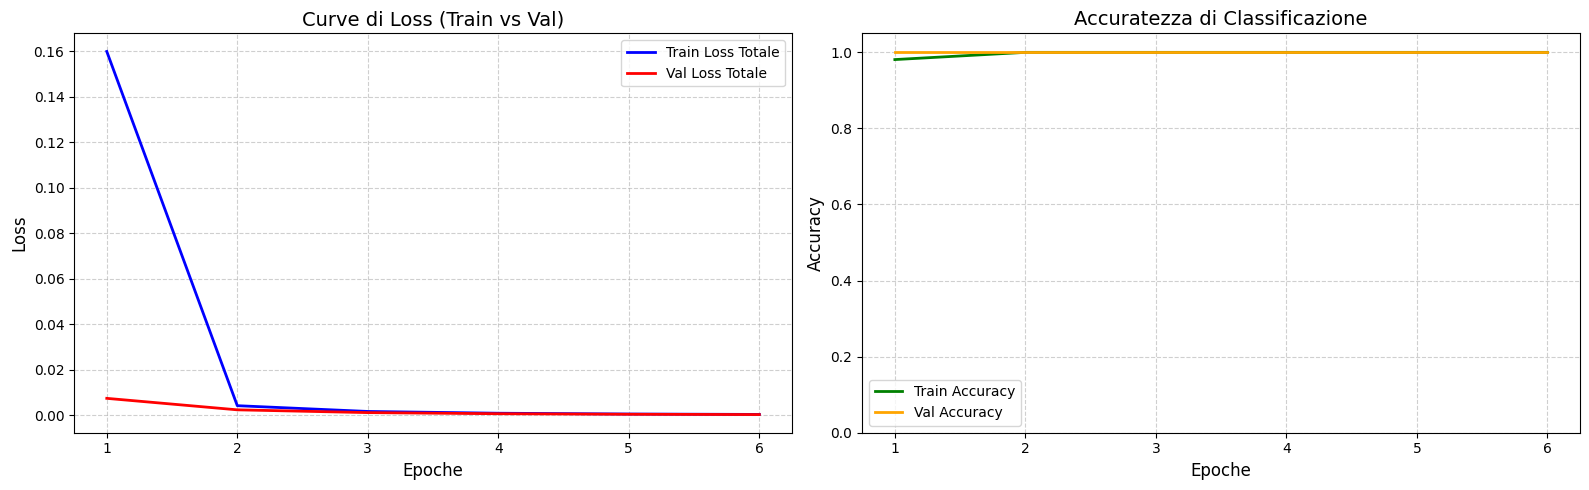

In [8]:
from src.utils.plot import plot_history
plot_history(b_history)

#### Oracle Test

In [9]:
accuracy, preds, labels, _, _, _ = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     oracle=True,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 100.00%


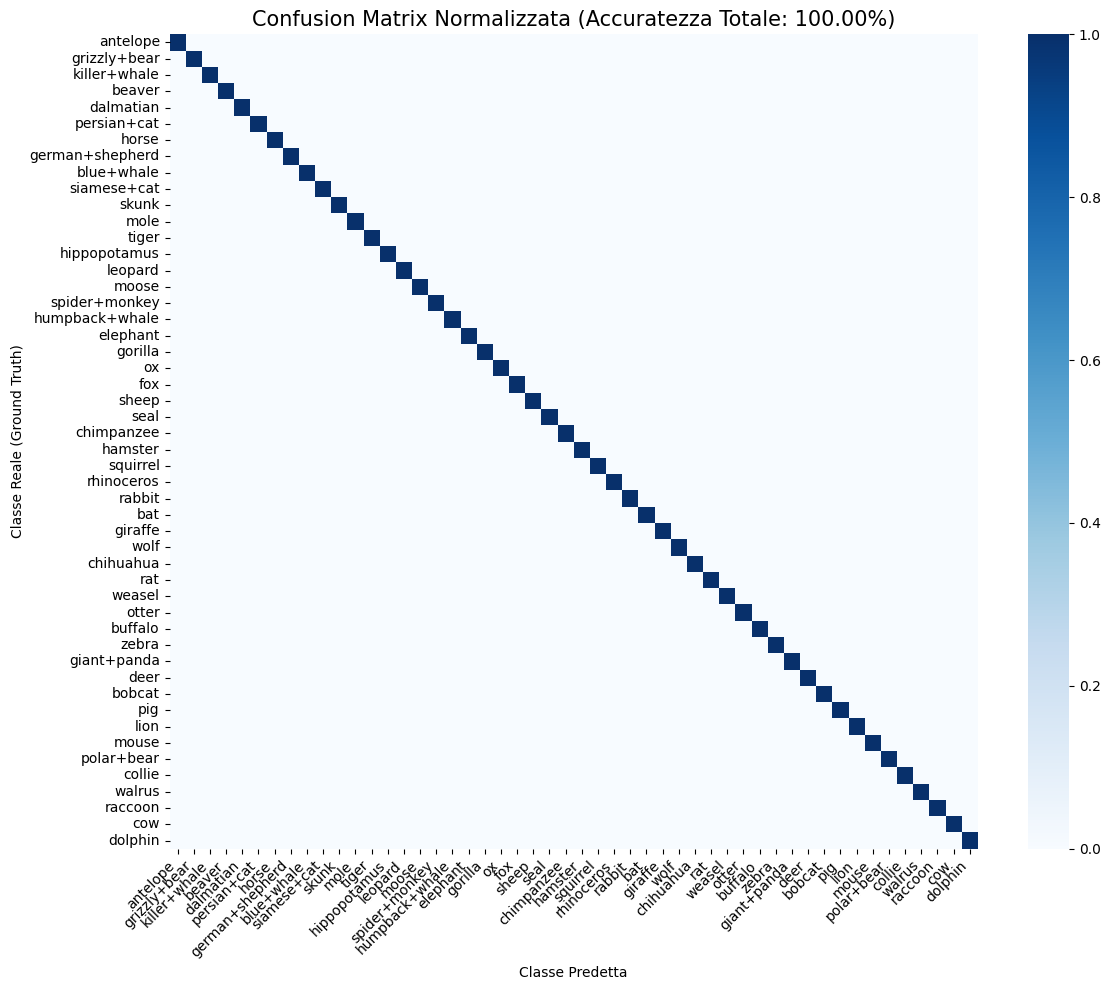


Analisi degli Errori Principali:


In [10]:
plot_test_results(accuracy, preds, labels, class_names=classes)

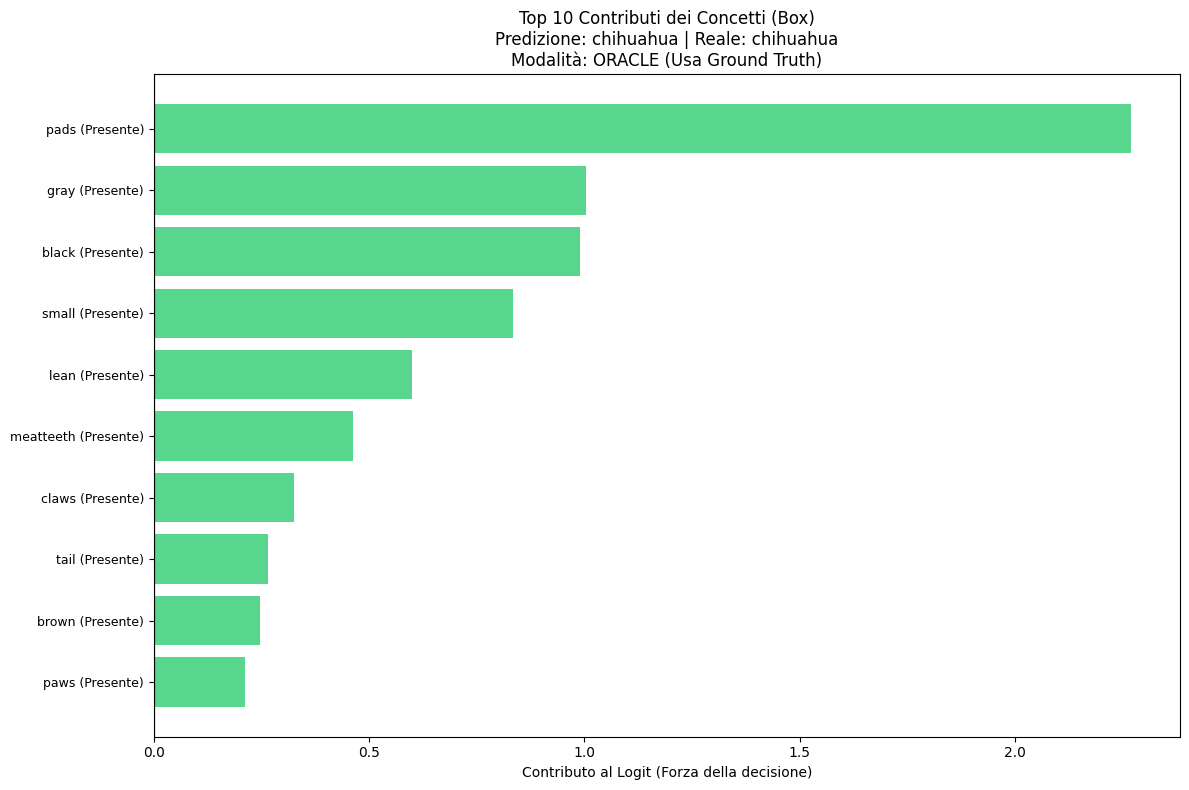

True

In [11]:
from src.CHM.interpretation import explain_prediction

explain_prediction(b_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, target_class="chihuahua")

### CBM with cond prob distrib

#### Train

In [12]:
info = "rel_matrix"
bipolar = True
cp_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(cp_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
cp_history = train_cbm_classifier(
    cp_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info,
    bipolar=bipolar
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/6 | TRAIN: Loss=0.146, Acc=98.3% | VAL: Loss=0.007, Acc=100.0%
Epoca   3/6 | TRAIN: Loss=0.004, Acc=100.0% | VAL: Loss=0.002, Acc=100.0%
Epoca   4/6 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   5/6 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   6/6 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   7/6 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Addestramento completato.


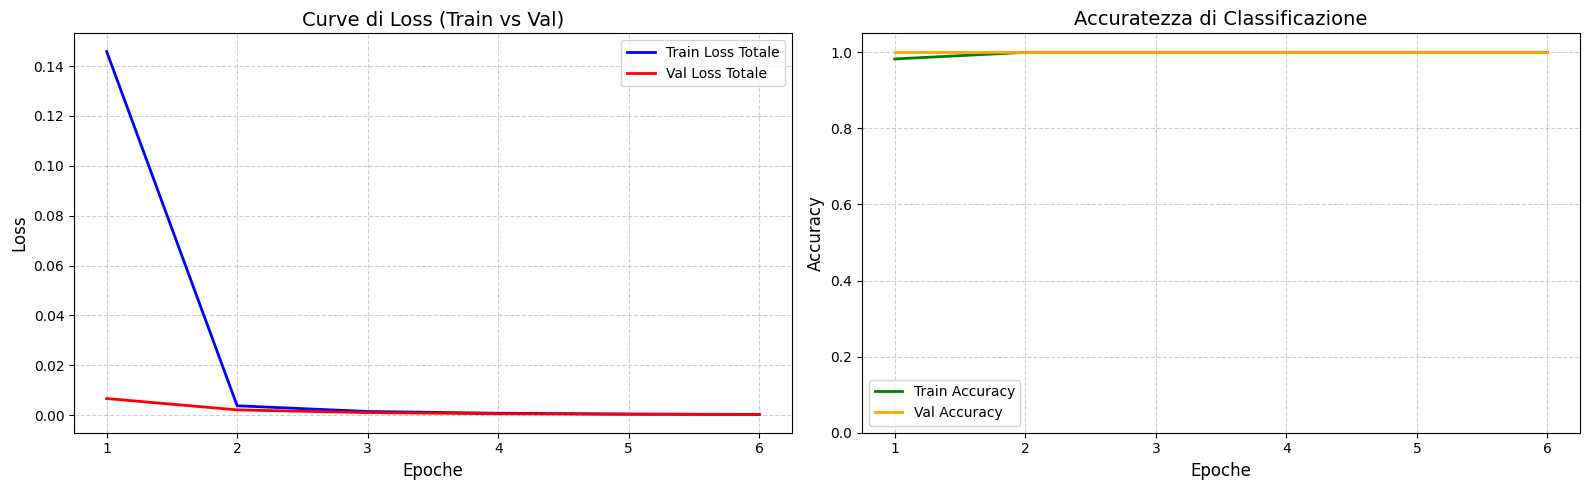

In [13]:
from src.utils.plot import plot_history
plot_history(cp_history)

#### Oracle Test

In [14]:
accuracy, preds, labels, _, _, _ = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=bipolar,
     oracle=True,
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 100.00%


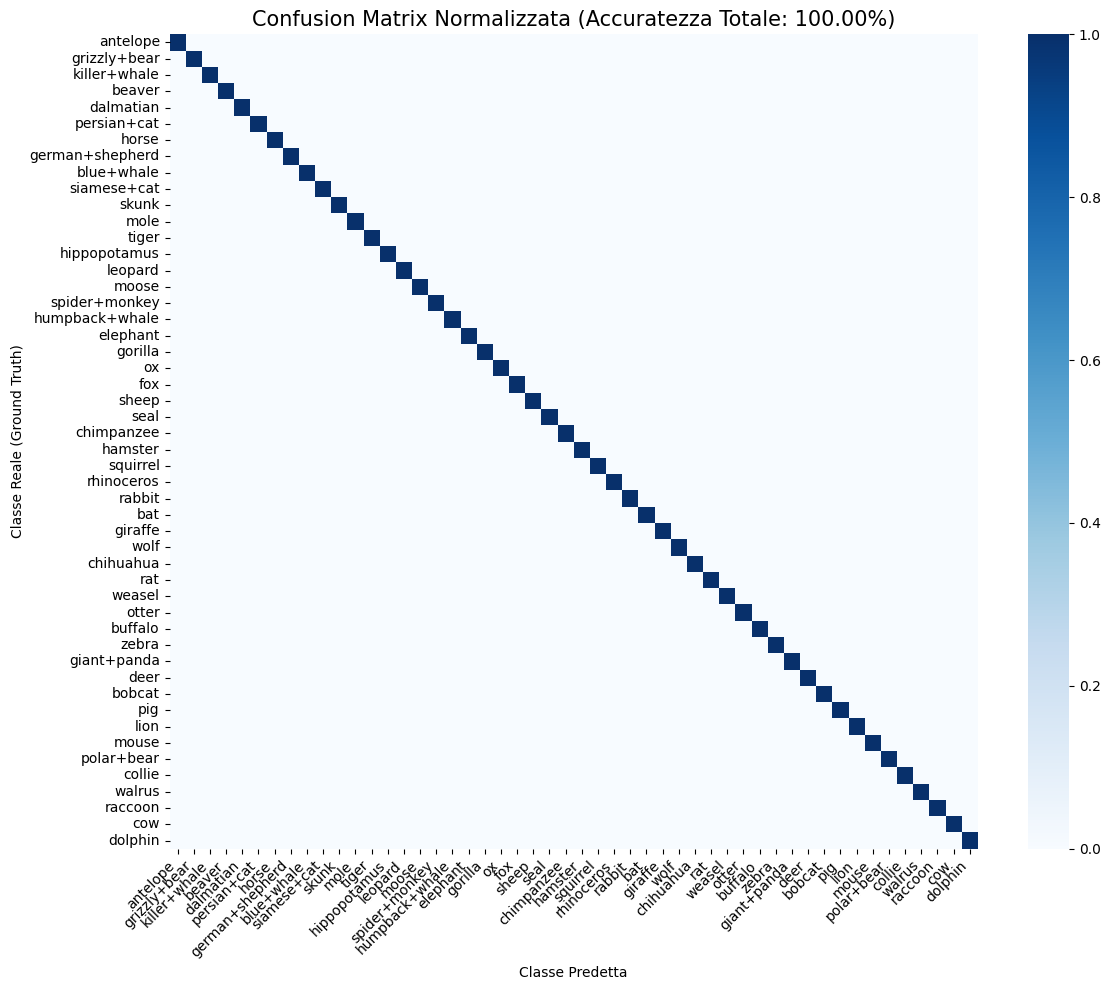


Analisi degli Errori Principali:


In [15]:
plot_test_results(accuracy, preds, labels, class_names=classes)

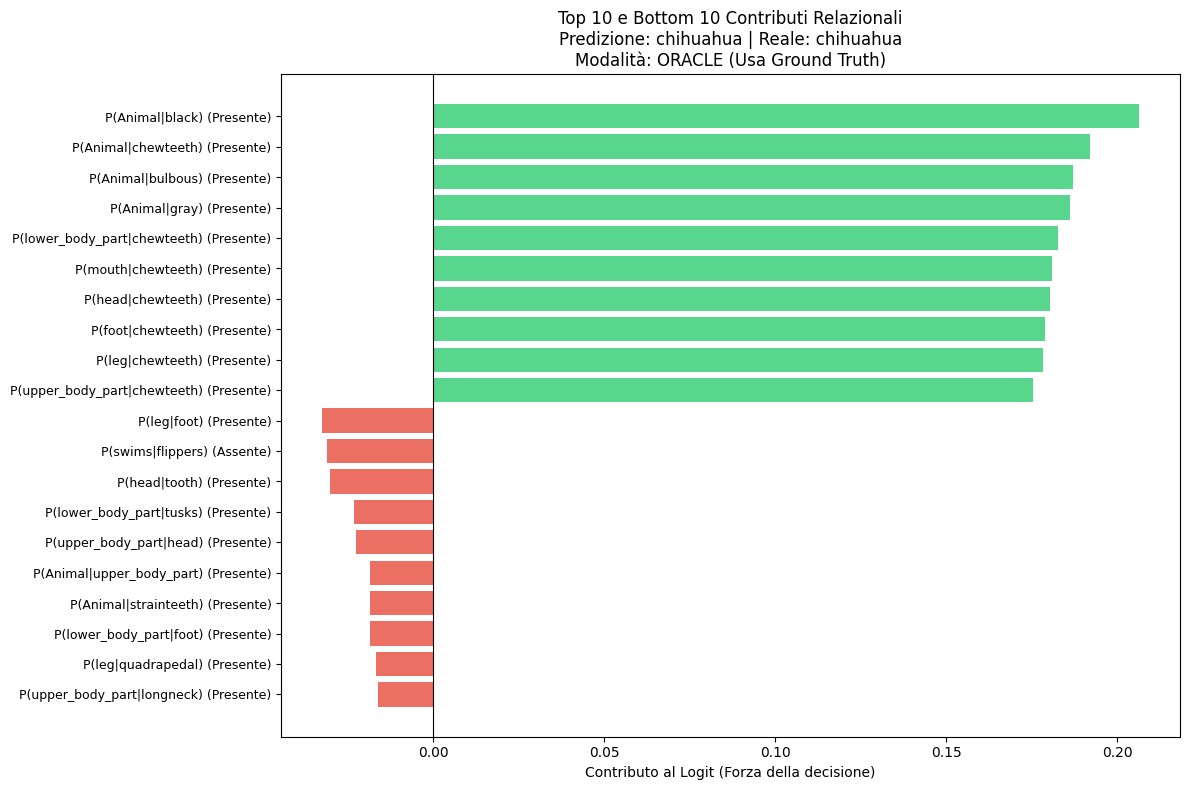

True

In [16]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_model, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors, 
    info_type=info, 
    target_class="chihuahua", 
    bipolar=bipolar
)

### CBM standard

In [17]:
info = "concepts"
c_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(c_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
c_history = train_cbm_classifier(
    c_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/6 | TRAIN: Loss=1.601, Acc=81.9% | VAL: Loss=0.514, Acc=98.1%
Epoca   3/6 | TRAIN: Loss=0.290, Acc=99.6% | VAL: Loss=0.160, Acc=100.0%
Epoca   4/6 | TRAIN: Loss=0.110, Acc=100.0% | VAL: Loss=0.074, Acc=100.0%
Epoca   5/6 | TRAIN: Loss=0.056, Acc=100.0% | VAL: Loss=0.041, Acc=100.0%
Epoca   6/6 | TRAIN: Loss=0.032, Acc=100.0% | VAL: Loss=0.025, Acc=100.0%
Epoca   7/6 | TRAIN: Loss=0.020, Acc=100.0% | VAL: Loss=0.016, Acc=100.0%
Addestramento completato.


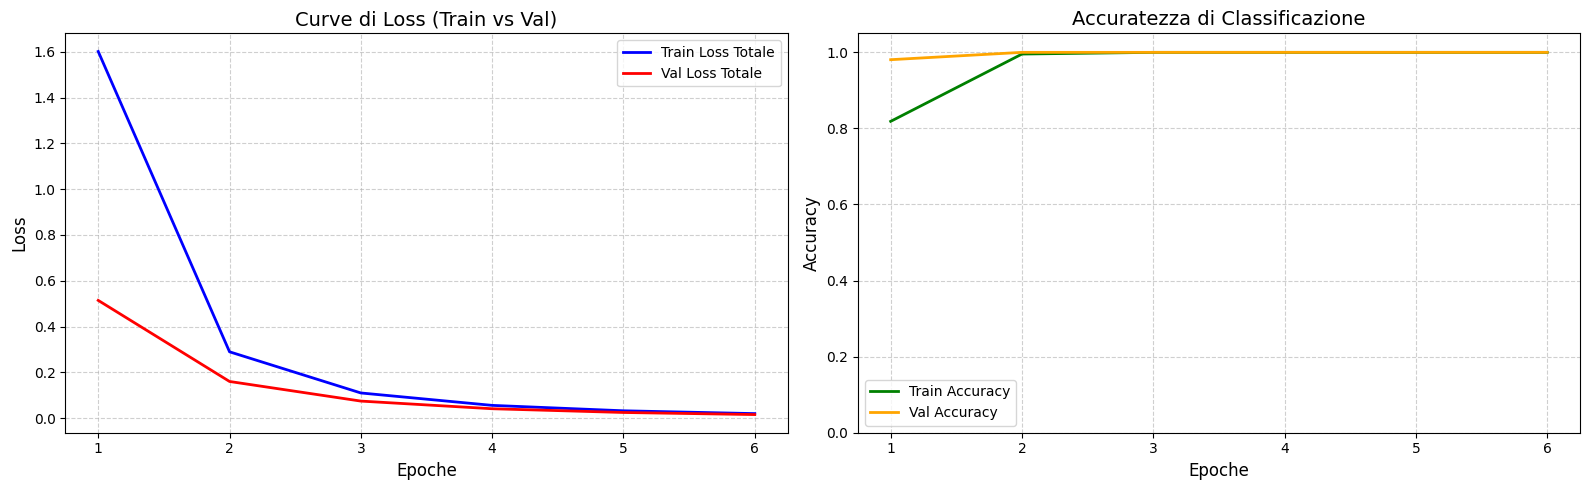

In [18]:
from src.utils.plot import plot_history
plot_history(c_history)

#### Oracle Test

In [19]:
accuracy, preds, labels, _, _, _ = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     oracle=True,
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 100.00%


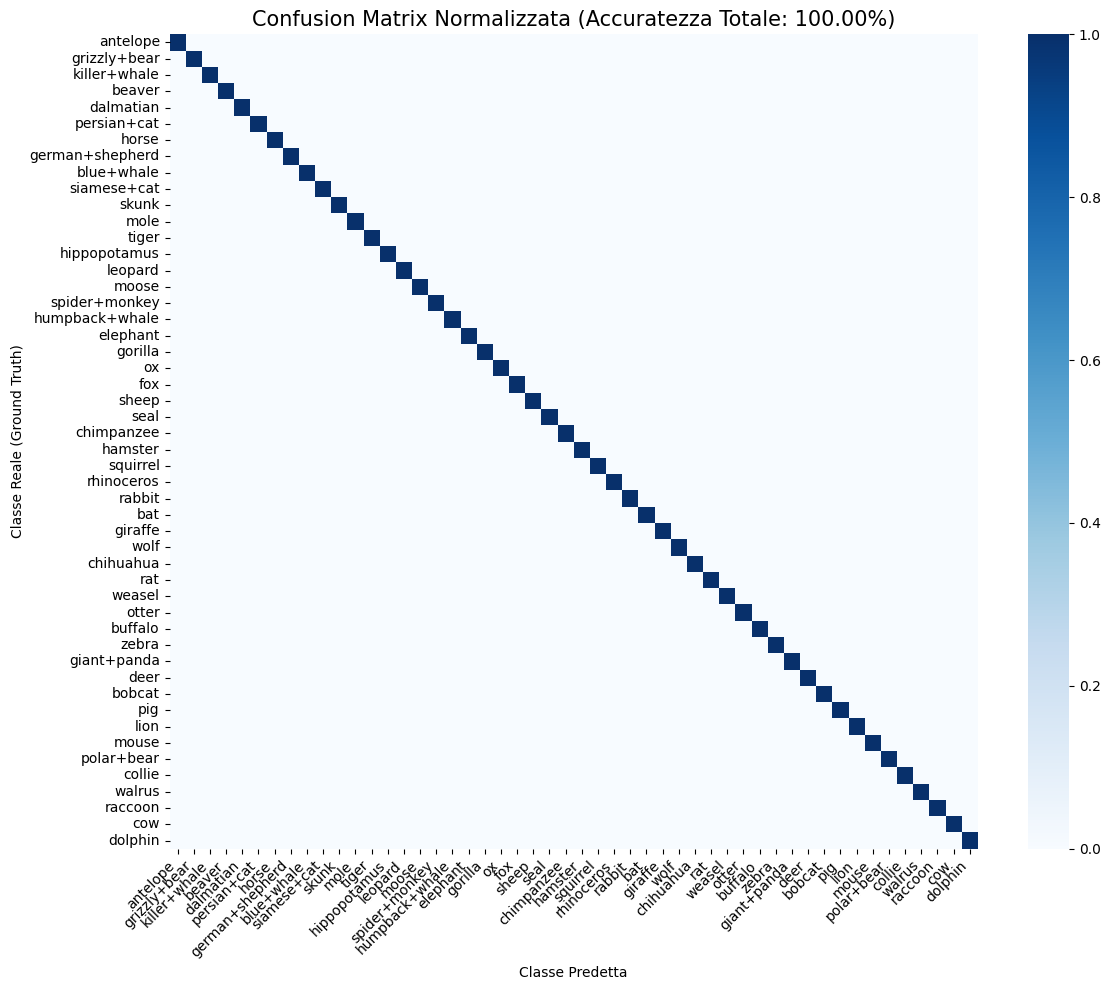


Analisi degli Errori Principali:


In [20]:
plot_test_results(accuracy, preds, labels, class_names=classes)

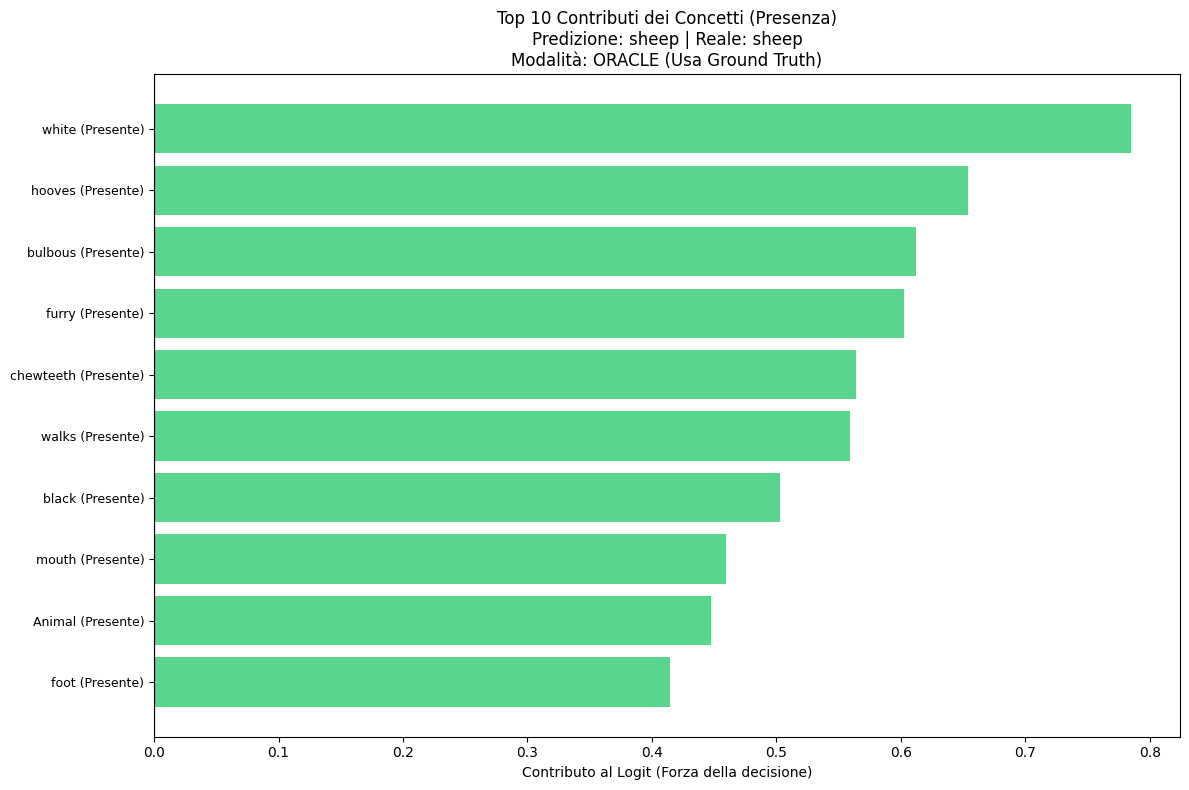

True

In [21]:
from src.CHM.interpretation import explain_prediction

explain_prediction(c_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, info_type=info)

## CBM GEOMETRIC CLASSIFIER

In [22]:
BOX_DIM = 16

info = 'dynamic_box'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

box_model = BoxHierarchyModelJoint(num_concepts=len(concepts), num_classes=len(classes), dim=BOX_DIM)
box_model.load_state_dict(torch.load("../../AwA2_Dataset_Labels/Animals_with_Attributes2/modello_gerarchia_joint.pth"))
W_geom = get_geometric_class_weights(box_model, len(classes), len(concepts), device)

In [23]:

concept_weights = box_model.concept_embeddings.weight
class_weights = box_model.class_embeddings.weight
info = 'dynamic_box'
db_model = ConceptBottleneckClassifier(
        num_concepts=len(concepts), 
        box_dim=BOX_DIM, 
        num_classes=len(classes), 
        info=info, 
        concept_embeddings=concept_weights,
        class_embeddings=class_weights
)
info = 'geometric'
g_model = ConceptBottleneckClassifier(
        num_concepts=len(concepts), 
        num_classes=len(classes), 
        box_dim=BOX_DIM, 
        info=info, 
        geometric_weights=W_geom
)

## CONCEPT PREDICTOR

In [24]:
from src.CP.model import ConceptPredictor

concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(concept_predictor.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

In [25]:
from src.CHM.train import train_concept_predictor

history = train_concept_predictor(
    concept_predictor, 
    train_dataloader, 
    val_dataloader, 
    class_concept_matrix, 
    optimizer, 
    criterion, 
    EPOCHS, 
    device
)

Loss: 3.5384 | Acc: 95.9584 || Val Loss: 2.6043 | Val Acc: 97.0356
Loss: 2.2461 | Acc: 97.4319 || Val Loss: 2.3615 | Val Acc: 97.2103
Loss: 1.9568 | Acc: 97.7457 || Val Loss: 2.2604 | Val Acc: 97.3732
Loss: 1.7792 | Acc: 97.9626 || Val Loss: 2.1576 | Val Acc: 97.4894
Loss: 1.6579 | Acc: 98.0905 || Val Loss: 2.1241 | Val Acc: 97.5328
Loss: 1.5596 | Acc: 98.1987 || Val Loss: 2.1608 | Val Acc: 97.5130


## INDEPENDENT TESTING

### BOXES LINEAR CLASSIFIER

In [26]:
info = "boxes"
b_accuracy, b_preds, b_labels, b_concepts_preds, b_concepts_truth, b_concepts_probs = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 90.03%


#### STATS 

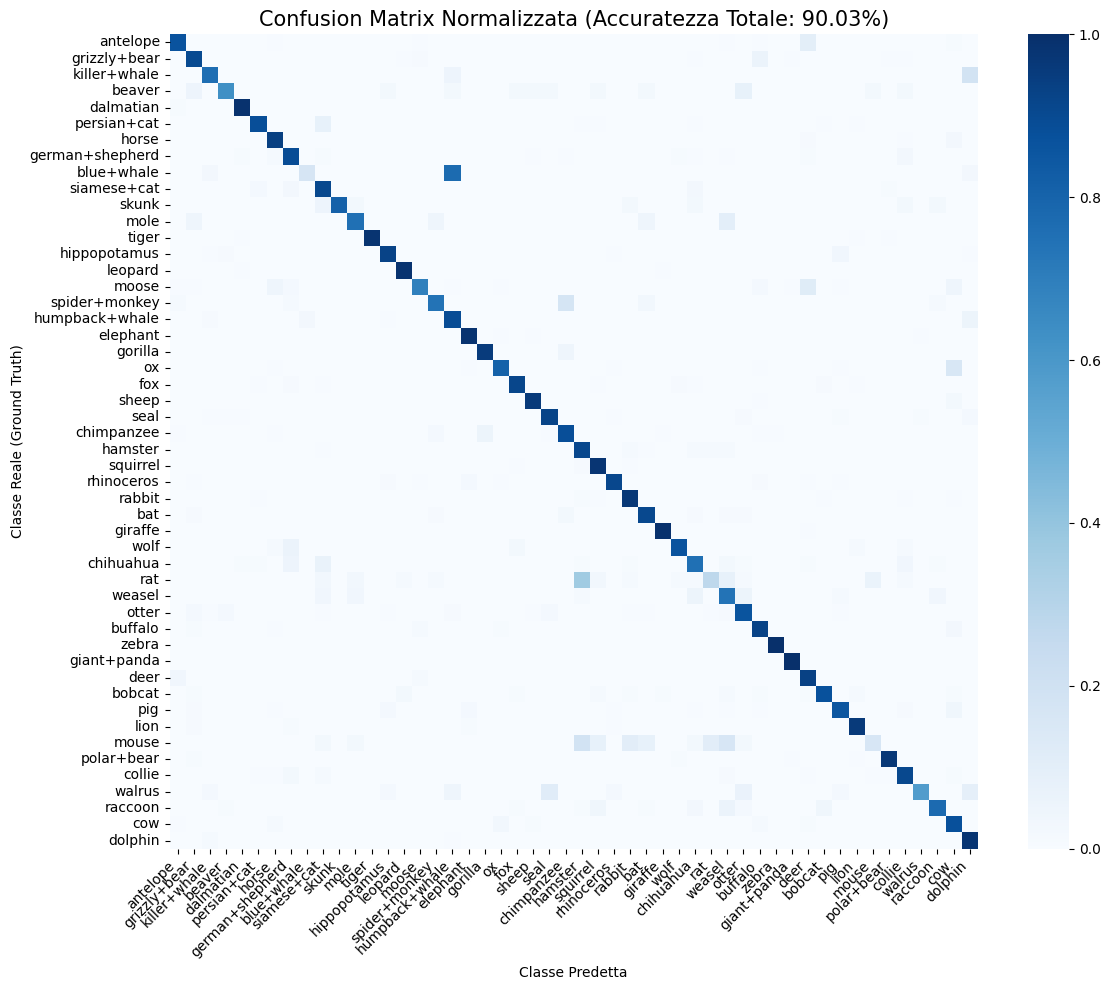


Analisi degli Errori Principali:
 - 27 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 23 volte: 'ox' è stato scambiato per 'cow'
 - 23 volte: 'rat' è stato scambiato per 'hamster'
 - 22 volte: 'antelope' è stato scambiato per 'deer'
 - 17 volte: 'moose' è stato scambiato per 'deer'


In [27]:
plot_test_results(b_accuracy, b_preds, b_labels, class_names=classes)

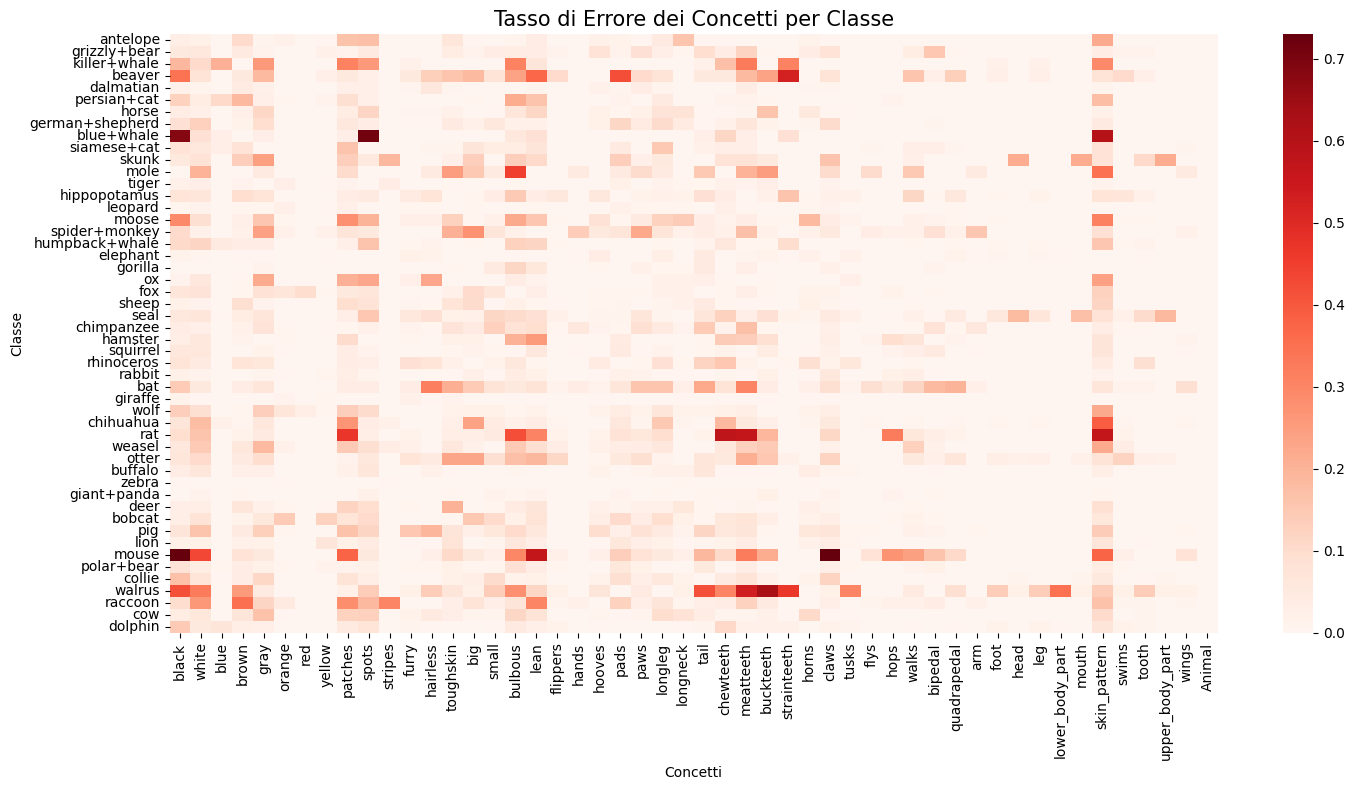

In [28]:
plot_concept_error_heatmap(labels,b_concepts_preds, b_concepts_truth, classes, concepts)

In [29]:
analyze_misclassifications_concepts(b_preds, b_labels, b_concepts_preds, b_concepts_truth, classes, concepts, num_examples=10)


--- ANALISI DEI CONCETTI SUGLI ERRORI (Mostrando 10 esempi) ---

[Esempio Errato #1 - Indice Batch: 3]
Classe Reale: 'collie' ---> Classe Predetta: 'polar+bear'
Concetti Sbagliati (Falsi Positivi / Falsi Negativi):
  - [brown] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [patches] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [small] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [bulbous] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [lean] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [pads] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [claws] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [skin_pattern] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.

[Esempio Errato #2 - Indice Batch: 7]
Classe Reale: 'walrus' ---> Classe Predetta: 'dolphin'
Concetti Sbagliati (Falsi Positivi / Falsi Negativi):
  - [black] Falso Positivo:

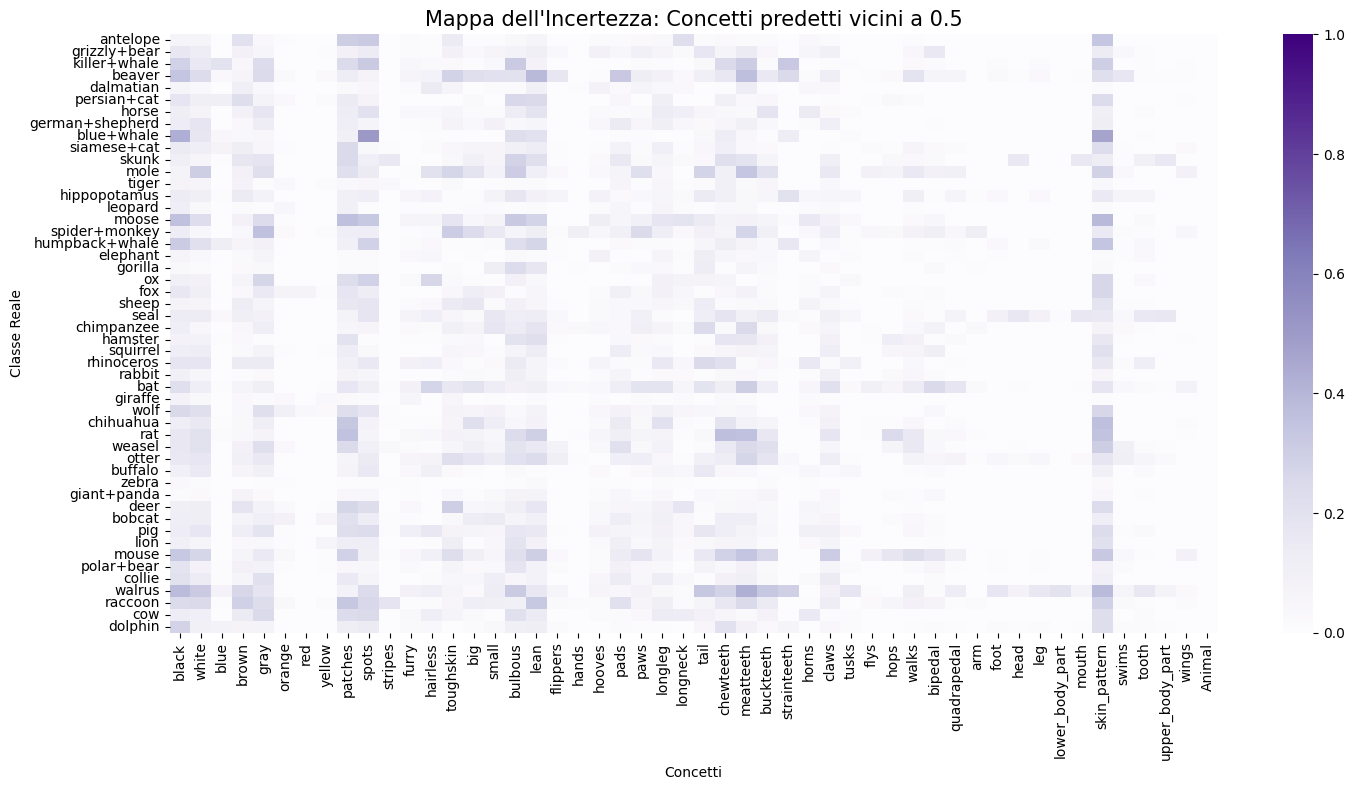

array([[6.94400445e-02, 6.87513128e-02, 3.57889687e-04, ...,
        9.85615588e-06, 6.56417105e-04, 5.23151948e-06],
       [1.62880912e-01, 1.36166736e-01, 7.95737433e-04, ...,
        1.16204168e-03, 4.76536341e-04, 1.15983630e-06],
       [2.85443127e-01, 1.53873563e-01, 1.98042840e-01, ...,
        1.03234837e-03, 8.38452391e-03, 2.44584567e-06],
       ...,
       [2.43657127e-01, 2.53857493e-01, 1.53879048e-02, ...,
        1.51356531e-03, 2.07417384e-02, 1.77177731e-06],
       [1.29499882e-01, 1.13748185e-01, 5.69456315e-04, ...,
        4.48613901e-05, 1.92740961e-04, 2.29700277e-06],
       [2.79847234e-01, 1.02502376e-01, 8.55343416e-02, ...,
        7.95321073e-03, 6.11090520e-03, 2.55448481e-06]])

In [30]:
plot_concept_uncertainty_heatmap(labels, b_concepts_probs, class_names=classes, concept_names=concepts)

#### TEST TIME INTERVENTION


--- Valutazione con k=0 interventi ---
Inizio valutazione sul Test Set...

Accuratezza Totale: 90.03%
Inizio valutazione sul Test Set...

Accuratezza Totale: 90.03%
Inizio valutazione sul Test Set...

Accuratezza Totale: 87.81%
Inizio valutazione sul Test Set...

Accuratezza Totale: 87.81%

--- Valutazione con k=1 interventi ---
Inizio valutazione sul Test Set...

Accuratezza Totale: 90.45%
Inizio valutazione sul Test Set...

Accuratezza Totale: 91.79%
Inizio valutazione sul Test Set...

Accuratezza Totale: 88.14%
Inizio valutazione sul Test Set...

Accuratezza Totale: 89.98%

--- Valutazione con k=2 interventi ---
Inizio valutazione sul Test Set...

Accuratezza Totale: 90.78%
Inizio valutazione sul Test Set...

Accuratezza Totale: 93.52%
Inizio valutazione sul Test Set...

Accuratezza Totale: 88.40%
Inizio valutazione sul Test Set...

Accuratezza Totale: 91.73%

--- Valutazione con k=3 interventi ---
Inizio valutazione sul Test Set...

Accuratezza Totale: 91.13%
Inizio valutazione su

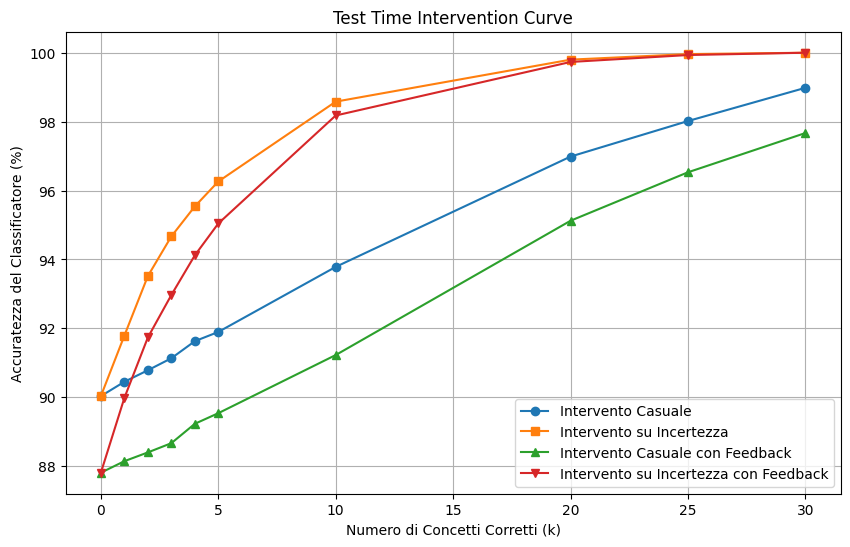

In [31]:
from src.utils.plot import plot_intervention_curve
plot_intervention_curve(
    k_values=[0,1,2,3,4,5,10,20,25,30],
    model=b_model,
    test_loader=test_dataloader,
    class_concept_matrix=class_concept_matrix,
    boxes_tensor=box_tensors,
    device=device,
    info=info,
    concept_predictor=concept_predictor
)

### RELATION MATRIX LINEAR CLASSIFIER

In [32]:
info = "rel_matrix"
cp_accuracy, cp_preds, cp_labels, cp_concepts_preds, cp_concepts_truth, cp_concepts_probs = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 75.00%


In [33]:
info = "rel_matrix"
cp_accuracy, cp_preds, cp_labels, cp_concepts_preds, cp_concepts_truth, cp_concepts_probs = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=True,
     oracle=False,
     concept_predictor=concept_predictor,
     smoothing_logic=False
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 89.66%


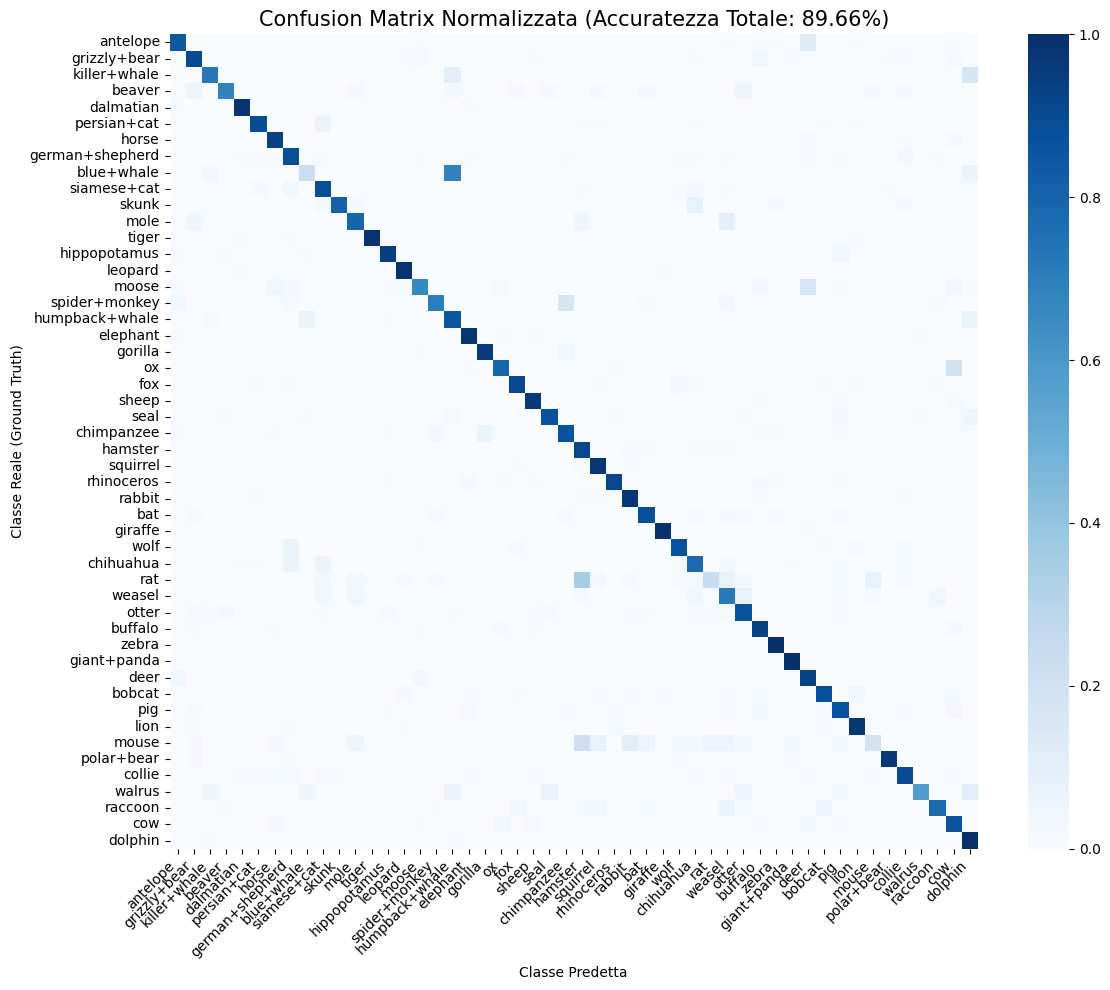


Analisi degli Errori Principali:
 - 28 volte: 'ox' è stato scambiato per 'cow'
 - 26 volte: 'antelope' è stato scambiato per 'deer'
 - 24 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 23 volte: 'moose' è stato scambiato per 'deer'
 - 22 volte: 'rat' è stato scambiato per 'hamster'


In [34]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

### STANDARD CBM LINEAR CLASSIFIER

In [35]:
info = "concepts"
c_accuracy, c_preds, c_labels, c_concepts_preds, c_concepts_truth, c_concepts_probs = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 90.02%


In [36]:
info = "concepts"
c_accuracy, c_preds, c_labels, c_concepts_preds, c_concepts_truth, c_concepts_probs = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor,
     smoothing_logic=True
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 87.25%


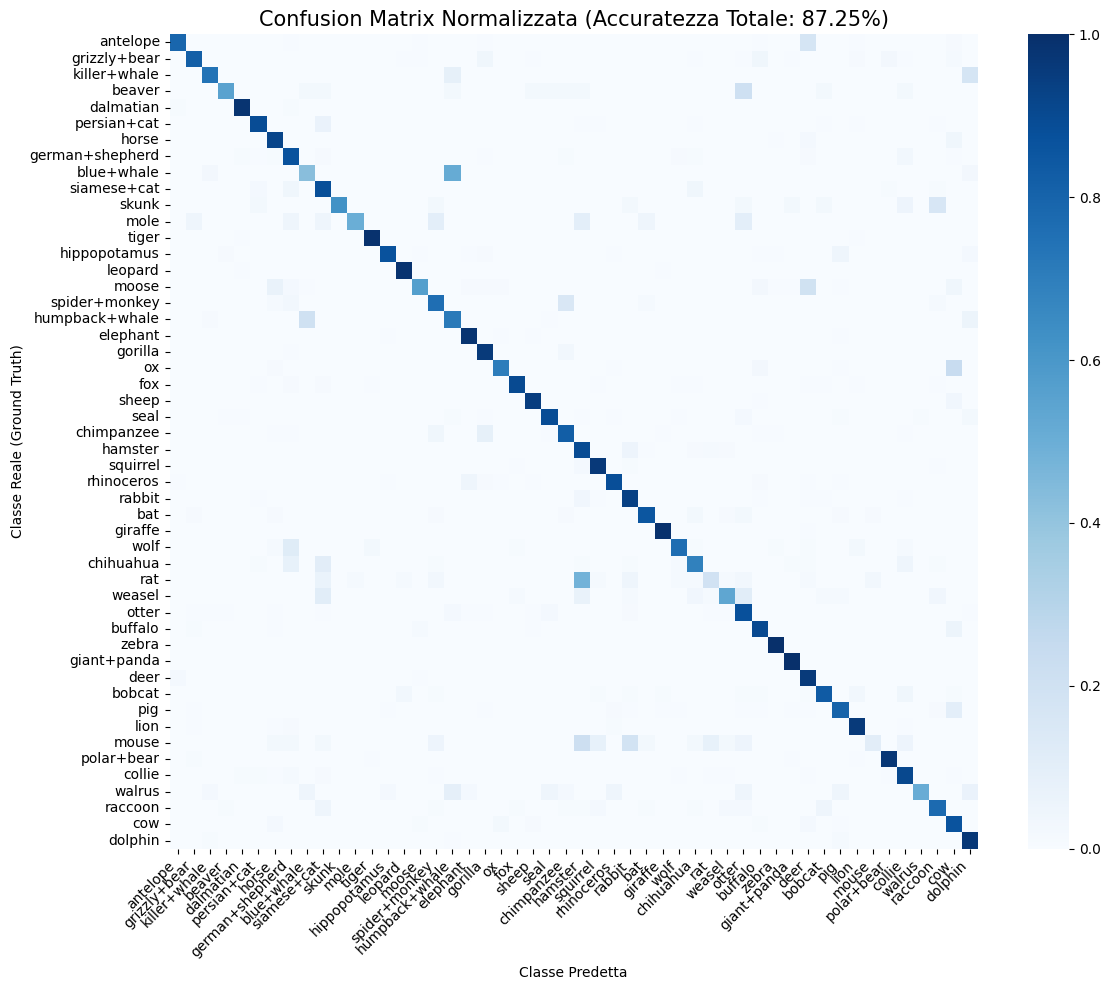


Analisi degli Errori Principali:
 - 36 volte: 'antelope' è stato scambiato per 'deer'
 - 35 volte: 'ox' è stato scambiato per 'cow'
 - 30 volte: 'rat' è stato scambiato per 'hamster'
 - 29 volte: 'humpback+whale' è stato scambiato per 'blue+whale'
 - 28 volte: 'moose' è stato scambiato per 'deer'


In [37]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)

### GEOMETRIC CLASSIFIER

### Oracle Test

In [38]:
box_tensors = None
info = "geometric"
g_accuracy, g_preds, g_labels, _, _, _ = test_cbm_classifier(
     model=g_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     oracle=True,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 88.12%


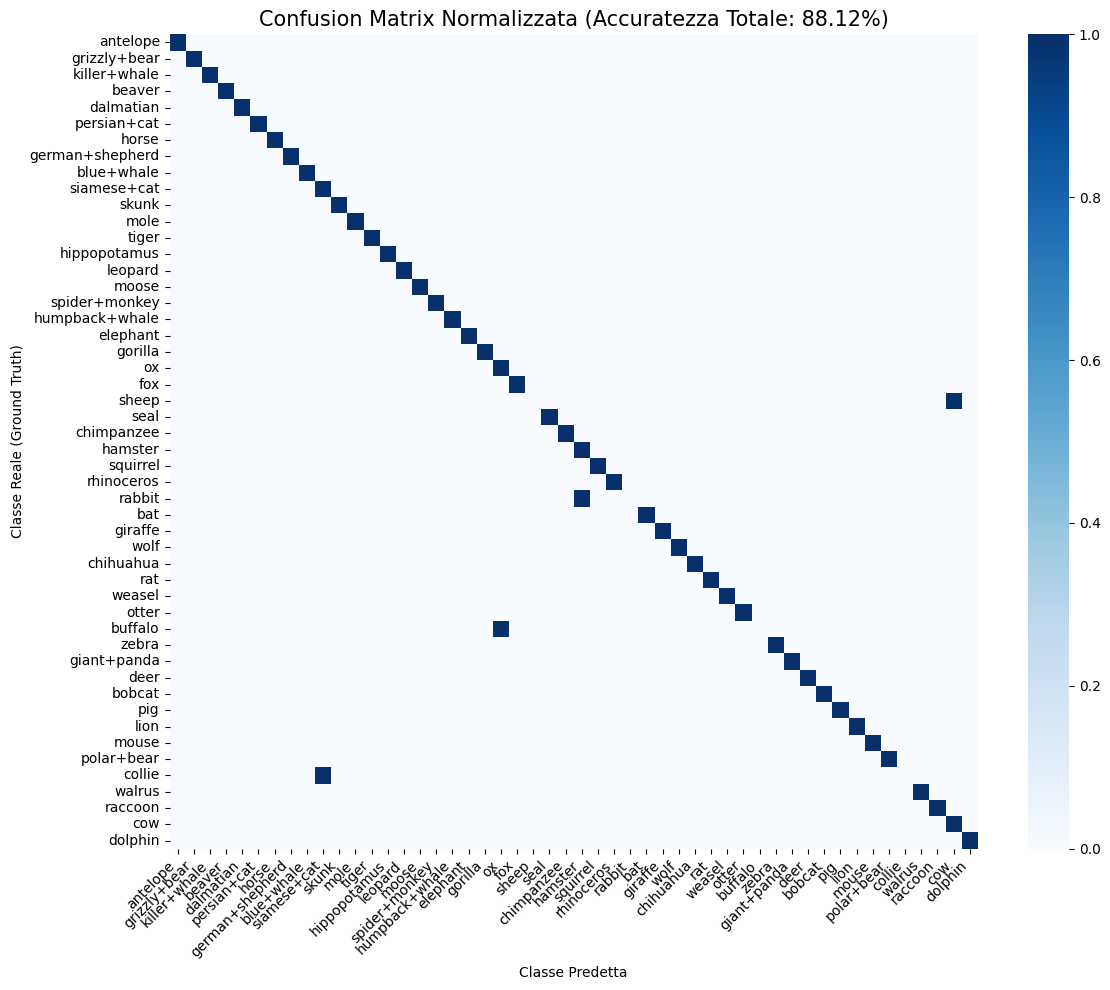


Analisi degli Errori Principali:
 - 284 volte: 'sheep' è stato scambiato per 'cow'
 - 218 volte: 'rabbit' è stato scambiato per 'hamster'
 - 206 volte: 'collie' è stato scambiato per 'siamese+cat'
 - 179 volte: 'buffalo' è stato scambiato per 'ox'


In [39]:
plot_test_results(g_accuracy, g_preds, g_labels, class_names=classes)

### Independent Test

In [40]:
g_accuracy, g_preds, g_labels, g_concepts_preds, g_concepts_truth, g_concepts_probs = test_cbm_classifier(
     model=g_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 71.44%


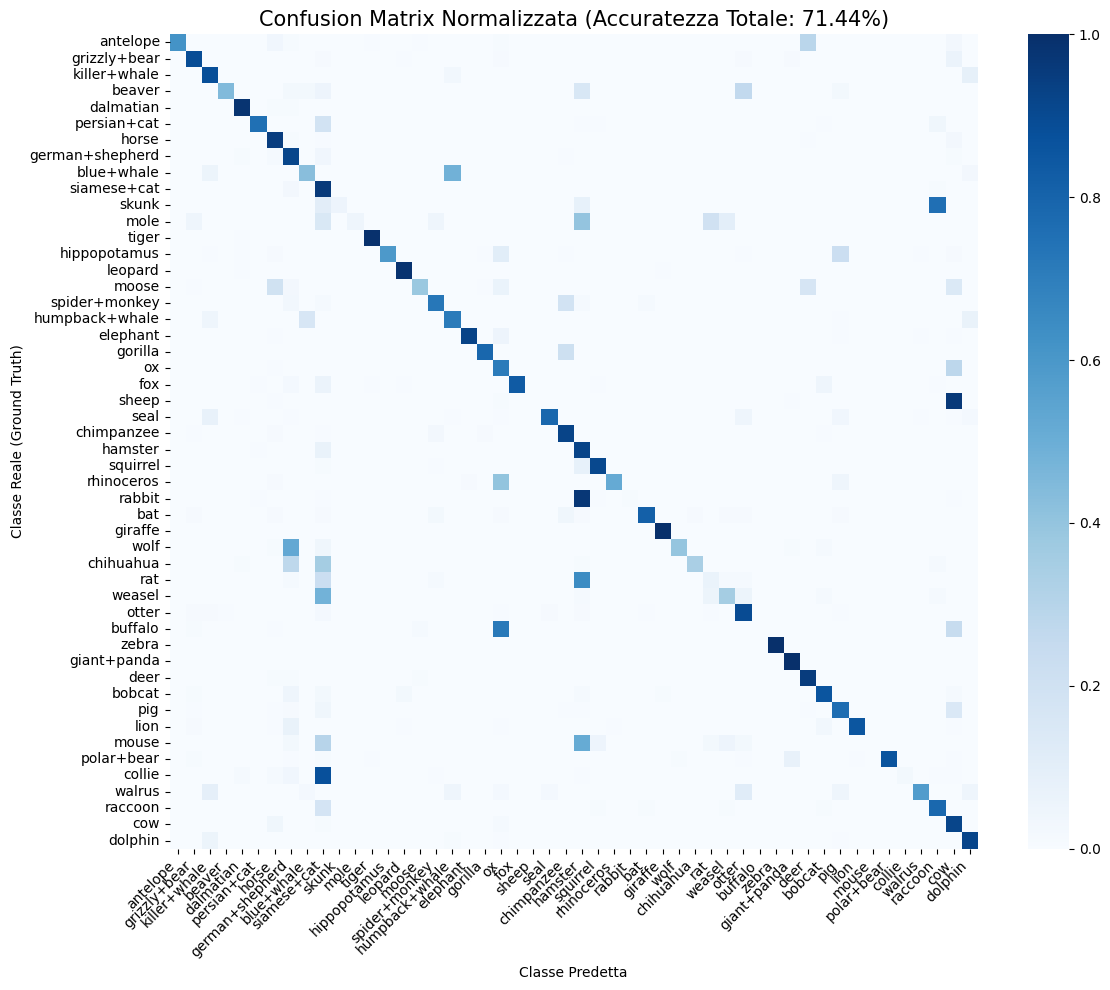


Analisi degli Errori Principali:
 - 274 volte: 'sheep' è stato scambiato per 'cow'
 - 212 volte: 'rabbit' è stato scambiato per 'hamster'
 - 181 volte: 'collie' è stato scambiato per 'siamese+cat'
 - 129 volte: 'buffalo' è stato scambiato per 'ox'
 - 62 volte: 'wolf' è stato scambiato per 'german+shepherd'


In [41]:
plot_test_results(g_accuracy, g_preds, g_labels, class_names=classes)

### DYNAMIC BOX CLASSIFIER

### Oracle Test

In [42]:
box_tensors = None
info = "dynamic_box"
db_accuracy, db_preds, db_labels, _, _, _ = test_cbm_classifier(
     model=db_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     oracle=True,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 74.39%


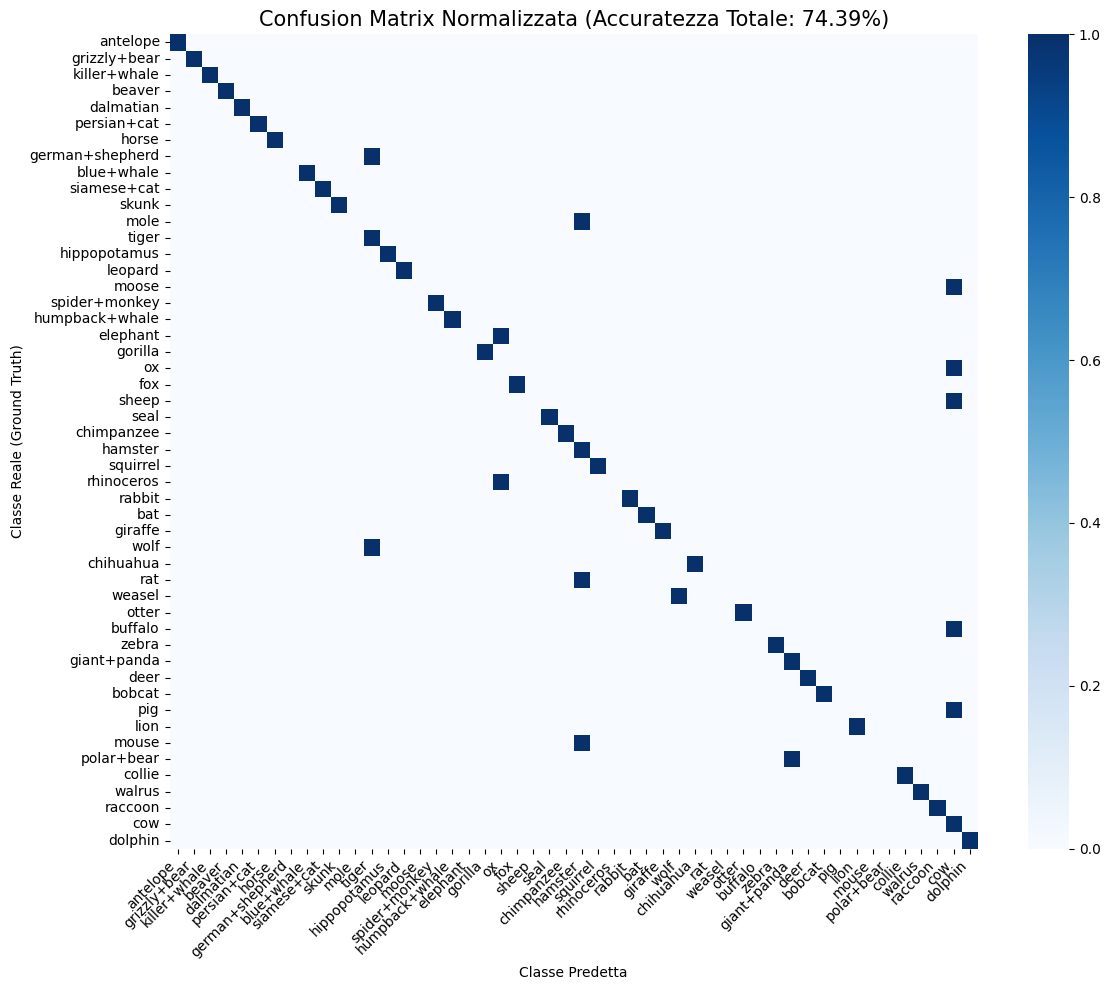


Analisi degli Errori Principali:
 - 284 volte: 'sheep' è stato scambiato per 'cow'
 - 208 volte: 'elephant' è stato scambiato per 'ox'
 - 207 volte: 'german+shepherd' è stato scambiato per 'tiger'
 - 179 volte: 'buffalo' è stato scambiato per 'cow'
 - 174 volte: 'polar+bear' è stato scambiato per 'giant+panda'


In [43]:
plot_test_results(db_accuracy, db_preds, db_labels, class_names=classes)

### Independent Test

In [44]:
db_accuracy, db_preds, db_labels, db_concepts_preds, db_concepts_truth, db_concepts_probs = test_cbm_classifier(
     model=db_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 54.86%


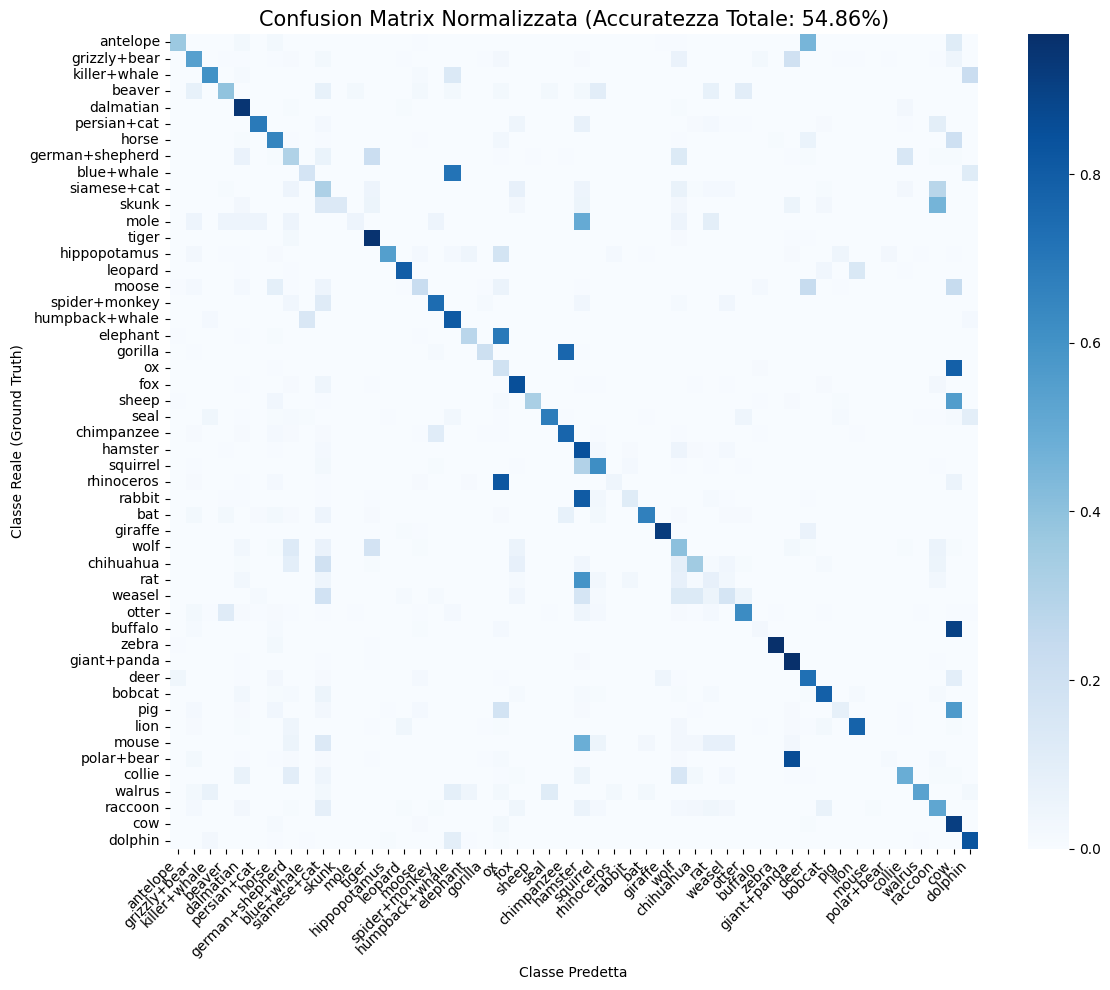


Analisi degli Errori Principali:
 - 176 volte: 'rabbit' è stato scambiato per 'hamster'
 - 162 volte: 'buffalo' è stato scambiato per 'cow'
 - 158 volte: 'sheep' è stato scambiato per 'cow'
 - 150 volte: 'polar+bear' è stato scambiato per 'giant+panda'
 - 145 volte: 'elephant' è stato scambiato per 'ox'


In [45]:
plot_test_results(db_accuracy, db_preds, db_labels, class_names=classes)